<a href="https://colab.research.google.com/github/ErikRidhoFirm/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MODUL 6 - Histogram, Histogram Equalization, Ditehring**

**TUGAS PRAKTIKUM**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**import beberapa library berikut yang akan digunakan selama uji coba praktikum minggu ke -6 berikut**

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# **3. Buatlah histogram citra seperti output histogram berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena.jpg).**

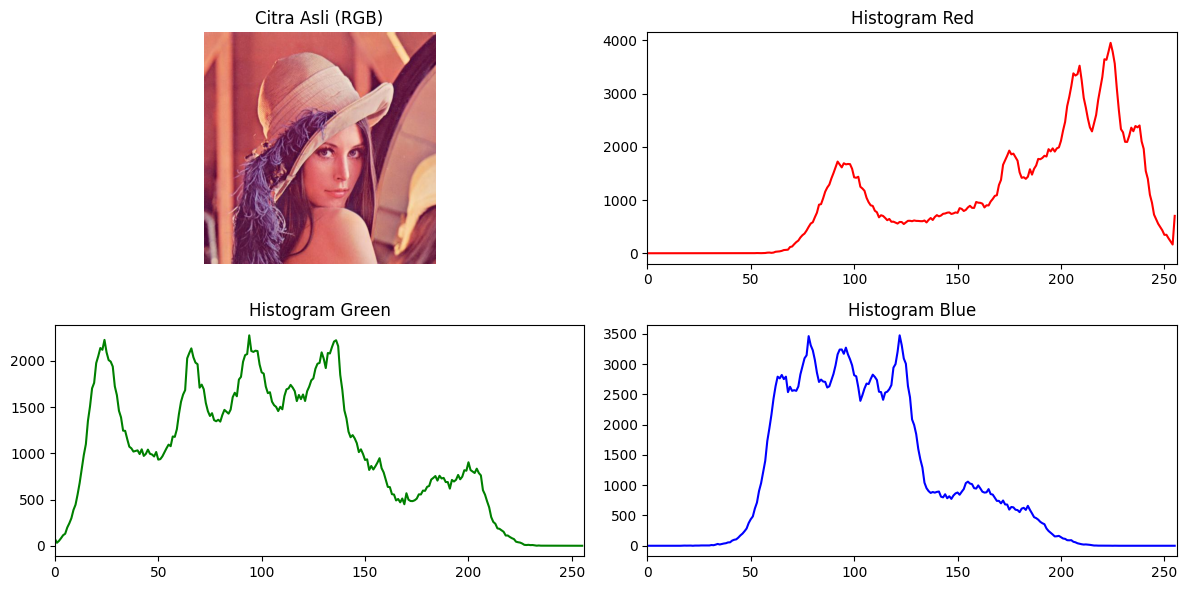

In [5]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Baca gambar (gambar yang dibaca, lena.jpg)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # ubah dari BGR ke RGB biar warnanya benar

# 2. Memisahkan channel warna
r, g, b = cv.split(img)

# 3. Hitung histogram masing-masing channel
hist_r = cv.calcHist([r], [0], None, [256], [0, 256])
hist_g = cv.calcHist([g], [0], None, [256], [0, 256])
hist_b = cv.calcHist([b], [0], None, [256], [0, 256])

# 4. Tampilkan gambar asli dan histogram
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(img)
plt.title('Citra Asli (RGB)')
plt.axis('off')

plt.subplot(2,2,2)
plt.plot(hist_r, color='red')
plt.title('Histogram Red')
plt.xlim([0,256])

plt.subplot(2,2,3)
plt.plot(hist_g, color='green')
plt.title('Histogram Green')
plt.xlim([0,256])

plt.subplot(2,2,4)
plt.plot(hist_b, color='blue')
plt.title('Histogram Blue')
plt.xlim([0,256])

plt.tight_layout()
plt.show()


#**3. Setelah mengerjakan soal no. 3, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?**

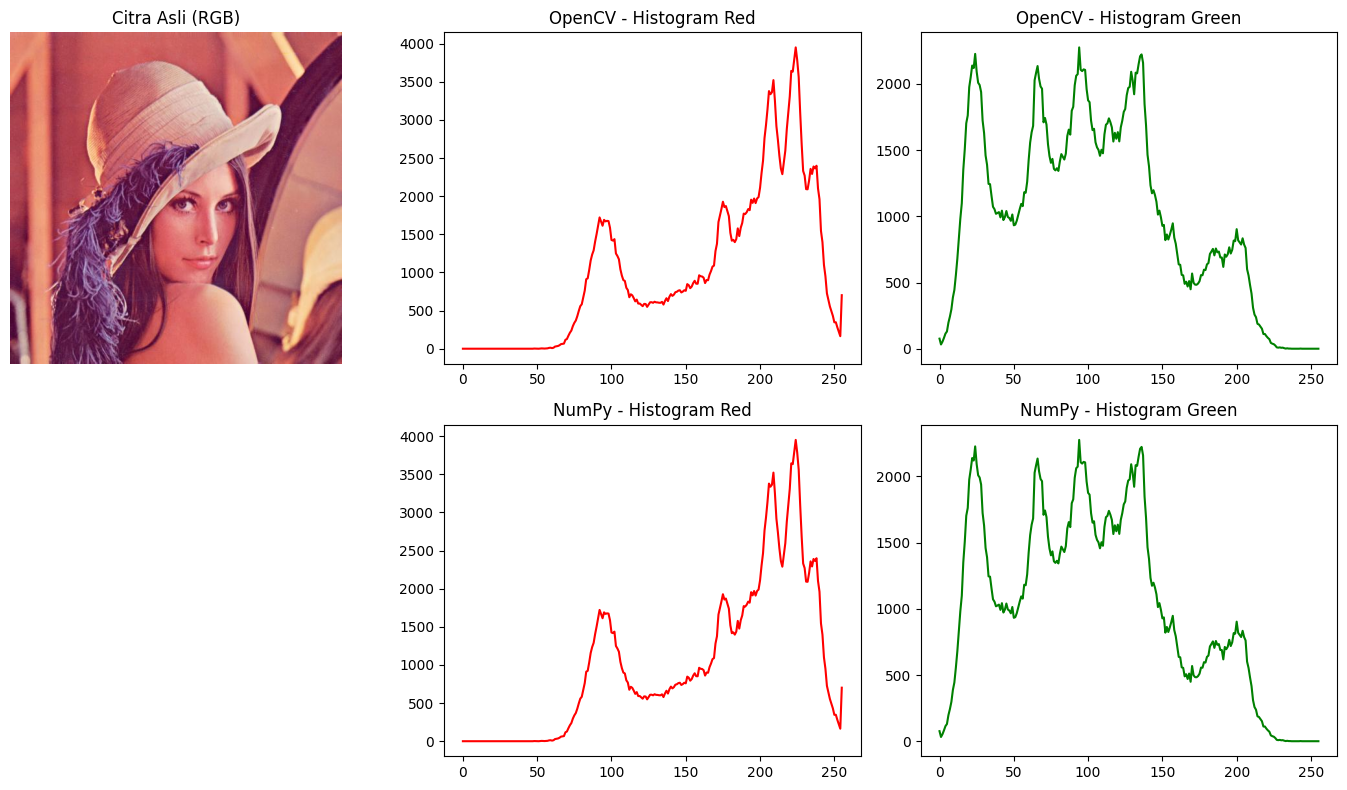

Apakah histogram Red sama?   → True
Apakah histogram Green sama? → True
Apakah histogram Blue sama?  → True


In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar (contoh: lena.jpg)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2. Pisahkan channel warna
r, g, b = cv.split(img)

# 3. Hitung histogram dengan OpenCV
hist_r_cv = cv.calcHist([r], [0], None, [256], [0, 256])
hist_g_cv = cv.calcHist([g], [0], None, [256], [0, 256])
hist_b_cv = cv.calcHist([b], [0], None, [256], [0, 256])

# 4. Hitung histogram dengan NumPy
hist_r_np, bins_r = np.histogram(r, bins=256, range=(0,256))
hist_g_np, bins_g = np.histogram(g, bins=256, range=(0,256))
hist_b_np, bins_b = np.histogram(b, bins=256, range=(0,256))

# 5. Tampilkan hasil untuk perbandingan
plt.figure(figsize=(14,8))

# --- Hasil OpenCV ---
plt.subplot(2,3,1)
plt.imshow(img)
plt.title('Citra Asli (RGB)')
plt.axis('off')

plt.subplot(2,3,2)
plt.plot(hist_r_cv, color='red')
plt.title('OpenCV - Histogram Red')

plt.subplot(2,3,3)
plt.plot(hist_g_cv, color='green')
plt.title('OpenCV - Histogram Green')

# --- Hasil NumPy ---
plt.subplot(2,3,5)
plt.plot(hist_r_np, color='red')
plt.title('NumPy - Histogram Red')

plt.subplot(2,3,6)
plt.plot(hist_g_np, color='green')
plt.title('NumPy - Histogram Green')

plt.tight_layout()
plt.show()

# 6. Bandingkan kesamaan nilai histogram
same_r = np.allclose(hist_r_cv.flatten(), hist_r_np)
same_g = np.allclose(hist_g_cv.flatten(), hist_g_np)
same_b = np.allclose(hist_b_cv.flatten(), hist_b_np)

print("Apakah histogram Red sama?   →", same_r)
print("Apakah histogram Green sama? →", same_g)
print("Apakah histogram Blue sama?  →", same_b)


# **4. Setelah mengerjakan soal no. 3, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?**

**HASIL ANALISA**

Secara numerik nilai histogram yang dihasilkan oleh kedua metode akan sama. Ini dikarenakan keduanya menghitung jumlah piksel dengan intensitas 0-255 untuk setiap warna. Namun ada sedikit perbedaan, yaitu dibagian bentuk output array dan tipe datanya.
* cv2.calcHist() dan,
* np.histogram().